# Icon example

This example draws the robodraw icon.

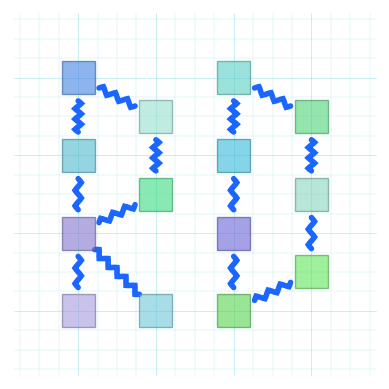

In [1]:
import robodraw

edges_lookup = {
    "D": [
        ((0, 0), (0, 1)),
        ((0, 1), (0, 2)),
        ((0, 2), (0, 3)),
        ((0, 3), (1, 2.5)),
        ((1, 2.5), (1, 1.5)),
        ((1, 1.5), (1, 0.5)),
        ((1, 0.5), (0, 0)),
    ],
    "R": [
        ((0, 0), (0, 1)),
        ((0, 1), (0, 2)),
        ((0, 2), (0, 3)),
        ((0, 3), (1, 2.5)),
        ((1, 2.5), (1, 1.5)),
        ((1, 1.5), (0, 1)),
        ((0, 1), (1, 0)),
    ],
}

r = 0.3

d = robodraw.Drawing()
for i, letter in enumerate("RD"):
    with d.translate(i * 2):
        edges = edges_lookup[letter]
        nodes = {v for edge in edges for v in edge}

        for cooa, coob in edges:
            d.zigzag(
                (cooa[0], cooa[1]),
                (coob[0], coob[1]),
                shorten=r,
                width=0.04,
                lw=4,
                color=(0.1, 0.4, 1.0),
            )
        for coo in nodes:
            color = robodraw.hash_to_color(
                str((coo, letter)), hmin=0.3, hmax=0.7
            )
            d.square(
                (coo[0], coo[1]),
                radius=r,
                hatch="",
                color=color,
                alpha=0.6,
                # linewidth=0,
            )

d.grid(ticklabels=False)
d.savefig("../_static/robodraw-icon.png")

In [2]:
from PIL import Image

img = Image.open("../_static/robodraw-icon.png")
img.save(
    "../_static/robodraw.ico",
    format="ICO",
    sizes=[(16, 16), (32, 32), (48, 48), (64, 64), (128, 128), (256, 256)],
)